In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import classification_report

## Importar o dataset direto do keras

In [5]:
from tensorflow.keras.datasets import mnist

## Carregamento dos dados

In [6]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

## Ver uma amostra

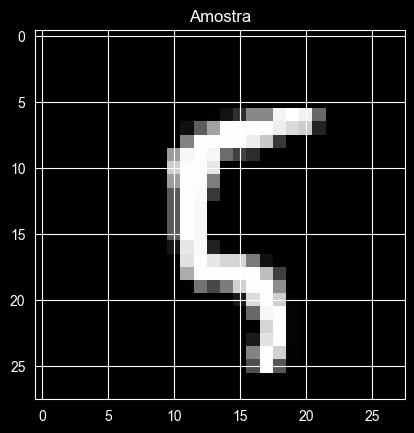

In [7]:
idx = 100
plt.figure()
plt.imshow(x_train[idx], cmap="gray")
plt.title("Amostra")
plt.show()

## Ver a matriz

In [8]:
idx = 300
matriz = x_train[idx].squeeze()
print(matriz)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 138 238
  217  68   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 150 254 254
  254 232   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  63 224 254 145
  254 240  22   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  15 160 253 25

## Pré-processamento

In [9]:
x_train = (x_train.astype("float32")/255.0)[...,None]
x_test = (x_test.astype("float32")/255.0)[...,None]
y_train_oh = tf.keras.utils.to_categorical(y_train,10)
y_test_oh = tf.keras.utils.to_categorical(y_test,10)

## Criação do modelo

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16,3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32,3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

## Compila definindo o Loss e métrica de avaliação

In [11]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

## Treino da CNN

In [12]:
history = model.fit(
    x_train, y_train_oh,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=2
)

Epoch 1/10
422/422 - 10s - loss: 0.2918 - accuracy: 0.9139 - val_loss: 0.0835 - val_accuracy: 0.9753 - 10s/epoch - 23ms/step
Epoch 2/10
422/422 - 9s - loss: 0.0850 - accuracy: 0.9732 - val_loss: 0.0716 - val_accuracy: 0.9788 - 9s/epoch - 22ms/step
Epoch 3/10
422/422 - 10s - loss: 0.0612 - accuracy: 0.9807 - val_loss: 0.0546 - val_accuracy: 0.9848 - 10s/epoch - 24ms/step
Epoch 4/10
422/422 - 9s - loss: 0.0494 - accuracy: 0.9843 - val_loss: 0.0455 - val_accuracy: 0.9878 - 9s/epoch - 20ms/step
Epoch 5/10
422/422 - 9s - loss: 0.0425 - accuracy: 0.9867 - val_loss: 0.0401 - val_accuracy: 0.9887 - 9s/epoch - 22ms/step
Epoch 6/10
422/422 - 8s - loss: 0.0361 - accuracy: 0.9887 - val_loss: 0.0438 - val_accuracy: 0.9873 - 8s/epoch - 19ms/step
Epoch 7/10
422/422 - 8s - loss: 0.0304 - accuracy: 0.9906 - val_loss: 0.0416 - val_accuracy: 0.9892 - 8s/epoch - 19ms/step
Epoch 8/10
422/422 - 8s - loss: 0.0266 - accuracy: 0.9916 - val_loss: 0.0397 - val_accuracy: 0.9892 - 8s/epoch - 20ms/step
Epoch 9/10
4

## Apresentar o resultado do modelo

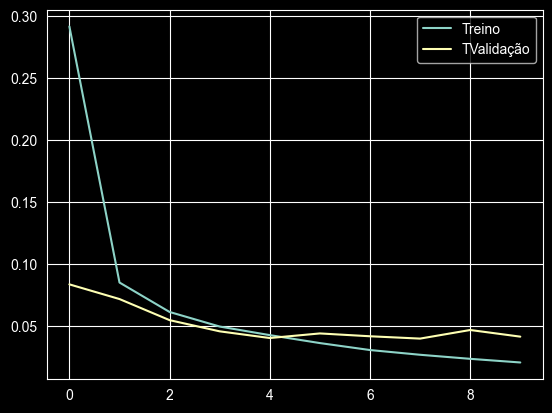

In [13]:
plt.plot(history.history["loss"],label="Treino")
plt.plot(history.history["val_loss"],label="TValidação")
plt.legend()

## Salvar Modelo

In [14]:
model.save("cnn_mnist_model.keras")
#importar o modelo
model = tf.keras.models.load_model("cnn_mnist_model.keras")

## Testar a predição do modelo

In [15]:
y_pred = np.argmax(model.predict(x_test, verbose = 0), axis = 1)
y_true = y_test

## Métricas de avaliação

In [16]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       1.00      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## Matriz de confusão

In [17]:
cm = tf.math.confusion_matrix(y_true, y_pred).numpy()

In [18]:
print(cm)

[[ 974    0    0    0    0    0    1    1    2    2]
 [   0 1133    0    1    0    0    1    0    0    0]
 [   2    2 1019    3    1    0    0    5    0    0]
 [   0    0    0 1003    0    4    0    0    2    1]
 [   0    0    0    0  973    0    0    1    1    7]
 [   2    0    1    9    0  875    1    2    0    2]
 [   3    3    0    0    1    2  948    0    1    0]
 [   0    3    1    1    0    0    0 1017    2    4]
 [   3    0    2    1    0    1    0    1  964    2]
 [   0    2    0    1    2    2    0    1    3  998]]


# HeatMap da matriz de confusão

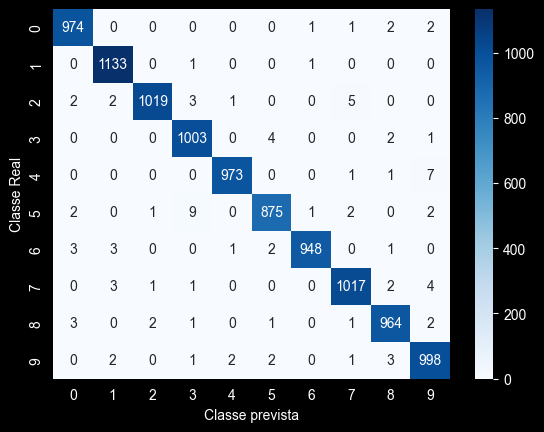

In [19]:
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("Classe prevista")
plt.ylabel("Classe Real")
plt.show()